In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

seeds = [42, 43, 44, 45, 46]
plot_dir = "/home/bbc8731/BioMedFormer/data/plot/zero_shot/"

In [2]:
# read data for zero_shot
txgnn_results = pd.read_csv("/home/bbc8731/BioMedFormer/data/TxGNN_results/result_more_metrics.csv")
txgnn_zero_shot = txgnn_results.loc[txgnn_results['Split'] == 'complex_disease',:]

######################
# seperate indication and contraindication
indication_rows = []
contraindication_rows = []

for i in txgnn_zero_shot['Metric Name'].unique():
    metric_i = txgnn_zero_shot.loc[txgnn_zero_shot['Metric Name'] == i,:]

    for j in metric_i['Method'].unique():
        method_j = metric_i.loc[metric_i['Method'] == j,:]

        indi = method_j.loc[method_j['Task'] == 'indication', 'Metric']
        contra = method_j.loc[method_j['Task'] == 'contraindication', 'Metric']

        mean_indication = np.nanmean(indi) if not indi.empty else np.nan
        std_indication = np.nanstd(indi) if not indi.empty else np.nan
        indication_rows.append([j, i, mean_indication, std_indication])

        mean_contraindication = np.nanmean(contra) if not contra.empty else np.nan
        std_contraindication  = np.nanstd(contra)  if not contra.empty else np.nan
        contraindication_rows.append([j, i, mean_contraindication, std_contraindication])

# build final DataFrames
indication_res = pd.DataFrame(indication_rows, columns=['method','Metric','mean','std'])
contraindication_res = pd.DataFrame(contraindication_rows, columns=['method','Metric','mean','std'])

In [3]:
data_dir_biomedformer = "/home/bbc8731/BioMedFormer/data/result/biomedformer_atr_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250705_221211/"

Lp_test = pd.read_csv(os.path.join(data_dir_biomedformer, "LP_test.csv"))
recall_precision_test_random = pd.read_csv(os.path.join(data_dir_biomedformer, "hit_precision_test.csv"))

# Group by seed
grouped = Lp_test.groupby('seed')
grouped_recall = recall_precision_test_random.groupby('seed')

# Extract the first and second rows per seed
indication_aucs_netmedgpt = grouped.nth(0)['auc']
contraindication_aucs_netmedgpt = grouped.nth(1)['auc']

indication_recall100_netmedgpt = grouped_recall.nth(0)['hit']
contraindication_recall100_netmedgpt = grouped_recall.nth(1)['hit']

indication_precision100_netmedgpt = grouped_recall.nth(0)['precision']
contraindication_precision100_netmedgpt = grouped_recall.nth(1)['precision']


In [4]:
# AUC 
##############################################################################
# indication

# other methods
indication_aucs_other = indication_res.loc[indication_res['Metric'] == 'AUROC',:]

# NetMedGPT results
mean_indication_aucs_netmedgpt = round(indication_aucs_netmedgpt.mean(), 3)
std_indication_aucs_netmedgpt = round(indication_aucs_netmedgpt.std(), 3)

new_row = pd.DataFrame(
    [['NetMedGPT', 'AUROC', mean_indication_aucs_netmedgpt, std_indication_aucs_netmedgpt]],
    columns=['method','Metric','mean','std']
)
indication_aucs = pd.concat([indication_aucs_other, new_row], ignore_index=True)

##############################################################################
# contraindication
contraindication_aucs_other = contraindication_res.loc[contraindication_res['Metric'] == 'AUROC',:]
mean_contraindication_aucs = round(contraindication_aucs_netmedgpt.mean(), 3)
std_contraindication_aucs = round(contraindication_aucs_netmedgpt.std(), 3)

new_row = pd.DataFrame(
    [['NetMedGPT', 'AUROC', mean_contraindication_aucs, std_contraindication_aucs]],
    columns=['method','Metric','mean','std']
)
contraindication_aucs = pd.concat([contraindication_aucs_other, new_row], ignore_index=True)

indication_aucs

,method,Metric,mean,std
0,DSD-min,AUROC,0.490408,0.025640
1,KL-min,AUROC,0.483687,0.035244
2,JS-min,AUROC,0.485042,0.023311
3,HGT,AUROC,0.579516,0.087576
4,HAN,AUROC,0.656337,0.031749
5,RGCN,AUROC,0.545491,0.066292
6,BioBERT,AUROC,0.783853,0.037800
7,TxGNN,AUROC,0.910094,0.023766
8,Proximity,AUROC,0.519568,0.018529
9,NetMedGPT,AUROC,0.952000,0.015000


In [5]:
# Recall@100
##############################################################################
# indication
indication_recall100_other = indication_res.loc[indication_res['Metric'] == 'Recall@100',:]
mean_indication_recall100_netmedgpt = round(indication_recall100_netmedgpt.mean(), 3)
std_indication_recall100_netmedgpt = round(indication_recall100_netmedgpt.std(), 3)

new_row = pd.DataFrame(
    [['NetMedGPT', 'Recall@100', mean_indication_recall100_netmedgpt, std_indication_recall100_netmedgpt]],
    columns=['method','Metric','mean','std']
)
indication_recall100 = pd.concat([indication_recall100_other, new_row], ignore_index=True)

#############################################################################
# contraindication
contraindication_recall100_other = contraindication_res.loc[contraindication_res['Metric'] == 'Recall@100',:]
mean_contraindication_recall100_netmedgpt = round(contraindication_recall100_netmedgpt.mean(), 3)
std_contraindication_recall100_netmedgpt = round(contraindication_recall100_netmedgpt.std(), 3)

new_row = pd.DataFrame(
    [['NetMedGPT', 'Recall@100', mean_contraindication_recall100_netmedgpt, std_contraindication_recall100_netmedgpt]],
    columns=['method','Metric','mean','std']
)
contraindication_recall100 = pd.concat([contraindication_recall100_other, new_row], ignore_index=True)

indication_recall100

,method,Metric,mean,std
0,DSD-min,Recall@100,0.008057,0.003730
1,KL-min,Recall@100,0.010654,0.007884
2,JS-min,Recall@100,0.008485,0.004054
3,HGT,Recall@100,0.040819,0.039927
4,HAN,Recall@100,0.155996,0.030760
5,RGCN,Recall@100,0.079247,0.034792
6,BioBERT,Recall@100,0.077311,0.024987
7,TxGNN,Recall@100,0.404916,0.045979
8,Proximity,Recall@100,0.003401,0.002169
9,NetMedGPT,Recall@100,0.823000,0.036000


In [6]:
# precision@100
##############################################################################
# indication
indication_precision100_other = indication_res.loc[indication_res['Metric'] == 'Precision@100',:]
mean_indication_precision100_netmedgpt = round(indication_precision100_netmedgpt.mean(), 3)
std_indication_precision100_netmedgpt = round(indication_precision100_netmedgpt.std(), 3)

new_row = pd.DataFrame(
    [['NetMedGPT', 'Precision@100', mean_indication_precision100_netmedgpt, std_indication_precision100_netmedgpt]],
    columns=['method','Metric','mean','std']
)
indication_precision100 = pd.concat([indication_precision100_other, new_row], ignore_index=True)

#############################################################################
# contraindication
contraindication_precision100_other = contraindication_res.loc[contraindication_res['Metric'] == 'Precision@100',:]
mean_contraindication_precision100_netmedgpt = round(contraindication_precision100_netmedgpt.mean(), 3)
std_contraindication_precision100_netmedgpt = round(contraindication_precision100_netmedgpt.std(), 3)

new_row = pd.DataFrame(
    [['NetMedGPT', 'Precision@100', mean_contraindication_precision100_netmedgpt, std_contraindication_precision100_netmedgpt]],
    columns=['method','Metric','mean','std']
)
contraindication_precision100 = pd.concat([contraindication_precision100_other, new_row], ignore_index=True)

indication_precision100

,method,Metric,mean,std
0,DSD-min,Precision@100,0.000892,0.000381
1,KL-min,Precision@100,0.000753,0.000413
2,JS-min,Precision@100,0.000869,0.000297
3,HGT,Precision@100,0.002573,0.002195
4,HAN,Precision@100,0.006875,0.001852
5,RGCN,Precision@100,0.005108,0.002893
6,BioBERT,Precision@100,0.007883,0.002239
7,TxGNN,Precision@100,0.029383,0.008624
8,Proximity,Precision@100,0.000654,0.000573
9,NetMedGPT,Precision@100,0.058000,0.010000


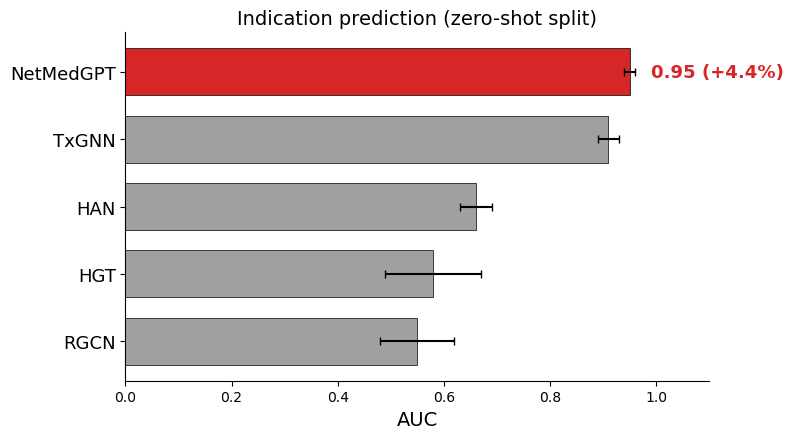

In [23]:
# plot AUC-indication
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(indication_aucs.loc[indication_aucs['method'] == i, 'mean'].item(), 2))
    stds.append(round(indication_aucs.loc[indication_aucs['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("Indication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_indication_zero_shot_AUC.png"), dpi=300, bbox_inches="tight")
plt.show()

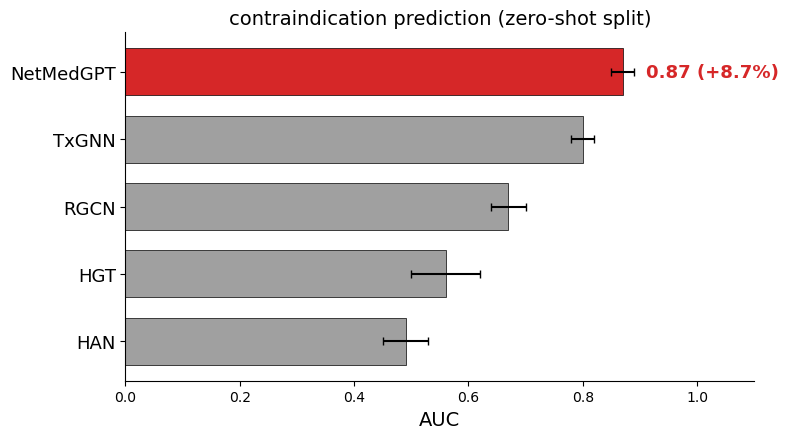

In [24]:
# plot AUC-contraindication
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []

for i in methods:
    means.append(round(contraindication_aucs.loc[contraindication_aucs['method'] == i, 'mean'].item(), 2))
    stds.append(round(contraindication_aucs.loc[contraindication_aucs['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUC", fontsize=14)
ax.set_title("contraindication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_contraindication_zero_shot_AUC.png"), dpi=300, bbox_inches="tight")
plt.show()

In [25]:
indication_recall100

,method,Metric,mean,std
0,DSD-min,Recall@100,0.008057,0.003730
1,KL-min,Recall@100,0.010654,0.007884
2,JS-min,Recall@100,0.008485,0.004054
3,HGT,Recall@100,0.040819,0.039927
4,HAN,Recall@100,0.155996,0.030760
5,RGCN,Recall@100,0.079247,0.034792
6,BioBERT,Recall@100,0.077311,0.024987
7,TxGNN,Recall@100,0.404916,0.045979
8,Proximity,Recall@100,0.003401,0.002169
9,NetMedGPT,Recall@100,0.823000,0.036000


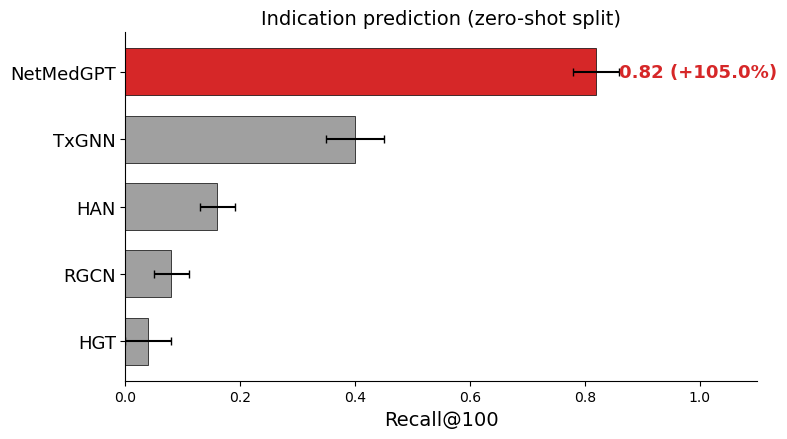

In [26]:
# plot Recall@100-indication
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(indication_recall100.loc[indication_recall100['method'] == i, 'mean'].item(), 2))
    stds.append(round(indication_recall100.loc[indication_recall100['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("Recall@100", fontsize=14)
ax.set_title("Indication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_indication_zero_shot_Recall@100.png"), dpi=300, bbox_inches="tight")
plt.show()

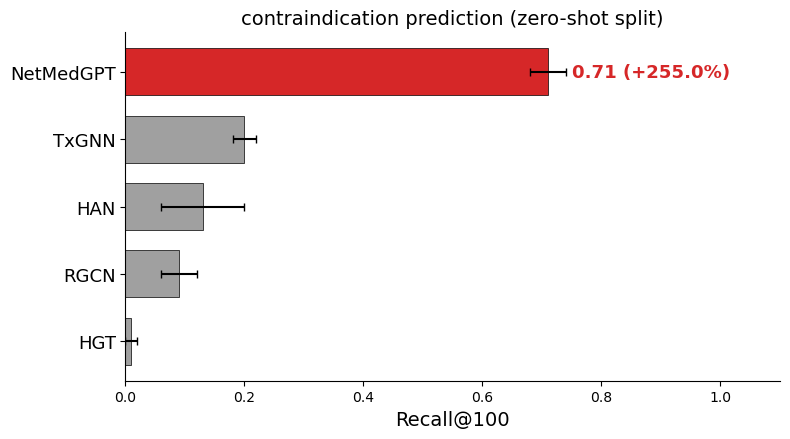

In [27]:
# plot Recall@100-contraindication
methods = ["RGCN", "HGT", "HAN","TxGNN", "NetMedGPT"]

means = []
stds = []
for i in methods:
    means.append(round(contraindication_recall100.loc[contraindication_recall100['method'] == i, 'mean'].item(), 2))
    stds.append(round(contraindication_recall100.loc[contraindication_recall100['method'] == i, 'std'].item(), 2))


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means[1:])
improvement = round((means[0] - baseline_max) / baseline_max * 100, 1)

# Colors: BioMedFormer = red, others = grey
colors = ['#D62728' if method == "NetMedGPT" else '#A0A0A0' for method in methods]

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "NetMedGPT":
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("Recall@100", fontsize=14)
ax.set_title("contraindication prediction (zero-shot split)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "netmedgpt_contraindication_zero_shot_Recall@100.png"), dpi=300, bbox_inches="tight")
plt.show()